# Task 3: Wavelet denoising and anomaly detection

In [1]:
import os
import pywt
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(0)
n = 1000
t = np.arange(n)
signal = rng.normal(0, 1, n)
signal.shape

(1000,)

In [3]:
wavelet = 'db4'
level = 4
coeffs = pywt.wavedec(signal, wavelet, level=level)

sigma = np.median(np.abs(coeffs[-1])) / 0.6745
thr = sigma * np.sqrt(2 * np.log(n))
coeffs[1:] = [pywt.threshold(c, thr, mode='soft') for c in coeffs[1:]]

denoised = pywt.waverec(coeffs, wavelet)[:n]
residuals = signal - denoised

limit = 2 * np.std(residuals)
anomalies = np.where(np.abs(residuals - residuals.mean()) > limit)[0]
print('threshold:', round(thr, 3), 'limit:', round(limit, 3))
print('anomalies found:', len(anomalies))

threshold: 3.72 limit: 1.891
anomalies found: 46


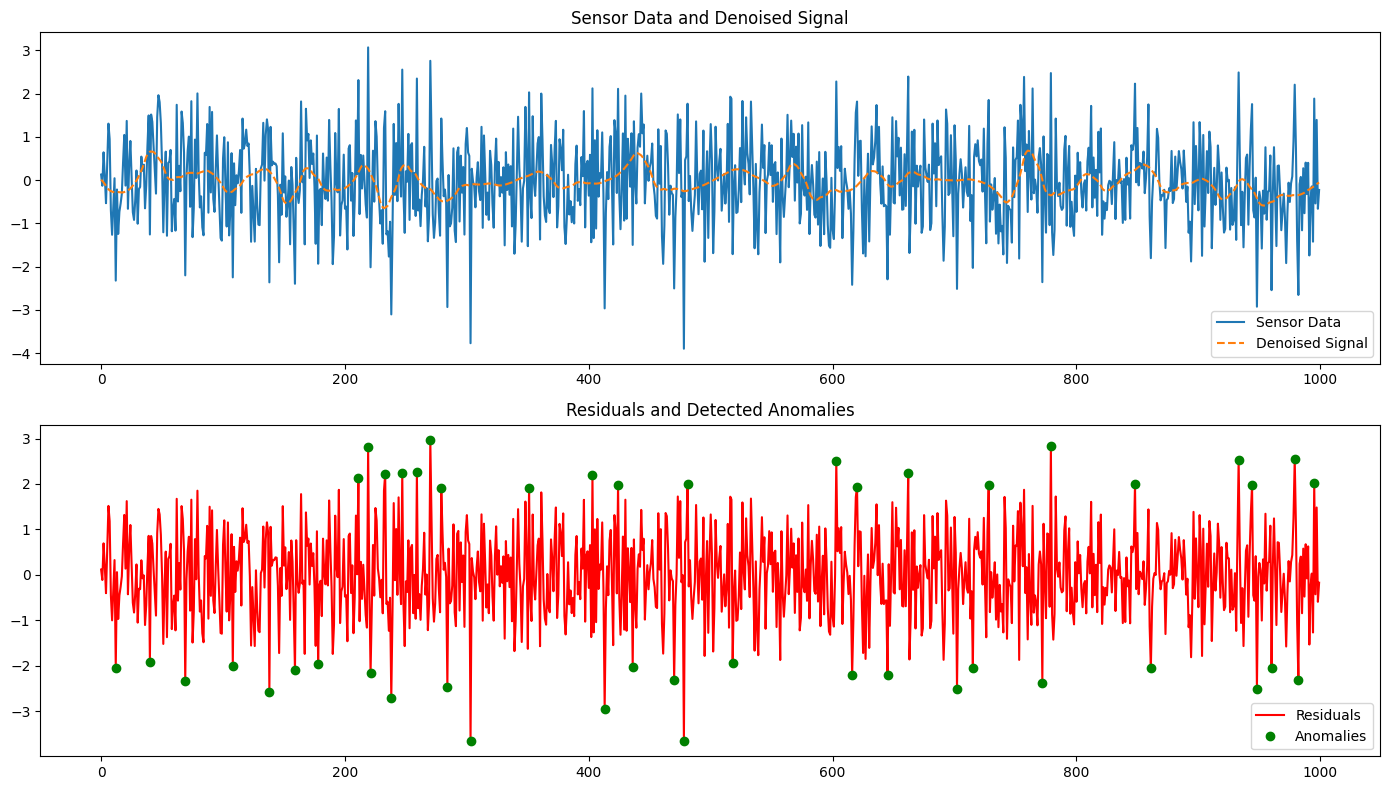

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(t, signal, label='Sensor Data')
axes[0].plot(t, denoised, '--', label='Denoised Signal')
axes[0].set_title('Sensor Data and Denoised Signal')
axes[0].legend(loc='lower right')

axes[1].plot(t, residuals, 'r', label='Residuals')
axes[1].plot(anomalies, residuals[anomalies], 'go', label='Anomalies')
axes[1].set_title('Residuals and Detected Anomalies')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()